In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings;warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import make_column_transformer, make_column_selector

In [8]:
hr = pd.read_csv('HR_comma_sep.csv')
X = hr.drop(['left'], axis=1)
y = hr['left']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [10]:
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
trns = make_column_transformer((ohe, make_column_selector(dtype_include=object)), remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
X_train_trns = trns.fit_transform(X_train)
X_test_trns = trns.transform(X_test)

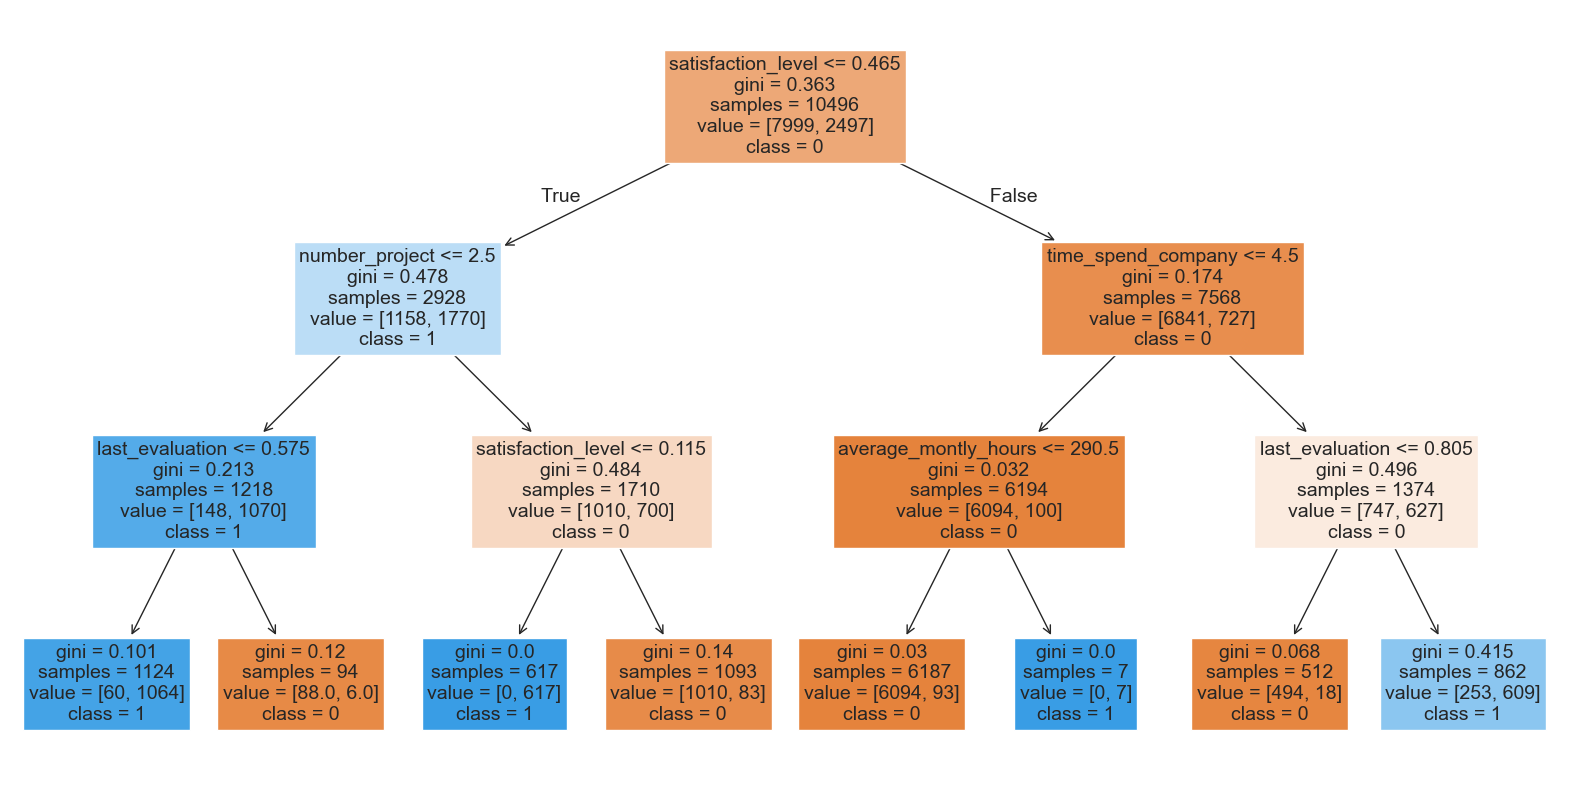

In [28]:
dtc = DecisionTreeClassifier(random_state=25, criterion='gini', max_depth=3)
dtc.fit(X_train_trns,y_train)
y_pred = dtc.predict(X_test_trns)
plt.figure(figsize=(20, 10))
plot_tree(dtc,
          feature_names=X_train_trns.columns,
          class_names=['0', '1'],
          filled=True,
          fontsize=14)
plt.show()

In [26]:
X_train_trns.iloc[-3]

Department_RandD            0.00
Department_accounting       1.00
Department_hr               0.00
Department_management       0.00
Department_marketing        0.00
Department_product_mng      0.00
Department_sales            0.00
Department_support          0.00
Department_technical        0.00
salary_low                  0.00
salary_medium               1.00
satisfaction_level          0.37
last_evaluation             0.47
number_project              2.00
average_montly_hours      138.00
time_spend_company          3.00
Work_accident               1.00
promotion_last_5years       0.00
Name: 12608, dtype: float64

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3429
           1       0.89      0.93      0.91      1070

    accuracy                           0.96      4499
   macro avg       0.93      0.95      0.94      4499
weighted avg       0.96      0.96      0.96      4499



In [35]:
depths = [3,4,5,6,7,8,9]
scores=[]
for d in depths:
    dtc = DecisionTreeClassifier(random_state=25, max_depth=d)
    dtc.fit(X_train_trns,y_train)
    y_pred = dtc.predict(X_test_trns)
    scores.append([d, f1_score(y_test,y_pred, pos_label=1)])
df_scores = pd.DataFrame(scores, columns=['depth', 'score'])
df_scores.sort_values(by='score', ascending=False, inplace=True)
df_scores

,depth,score
6,9,0.962751
4,7,0.959770
5,8,0.959311
3,6,0.955981
2,5,0.951382
1,4,0.934967
0,3,0.909672


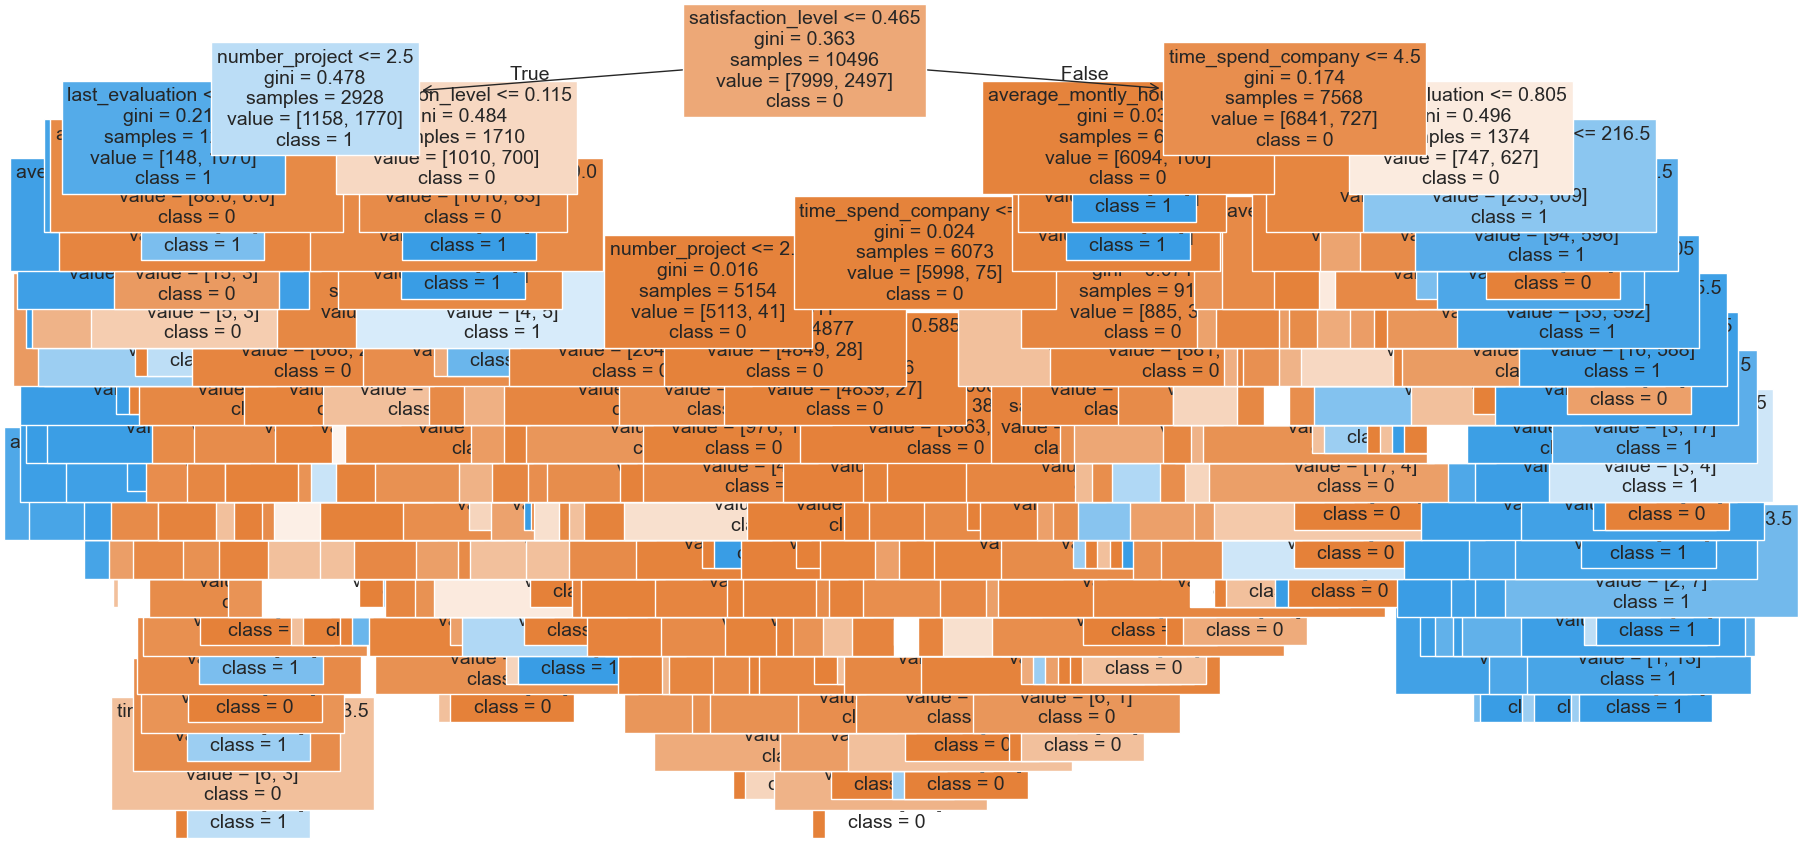

In [36]:
dtc = DecisionTreeClassifier(random_state=25, criterion='gini', min_samples_leaf=3)
dtc.fit(X_train_trns,y_train)
y_pred = dtc.predict(X_test_trns)
plt.figure(figsize=(20, 10))
plot_tree(dtc,
          feature_names=X_train_trns.columns,
          class_names=['0', '1'],
          filled=True,
          fontsize=14)
plt.show()

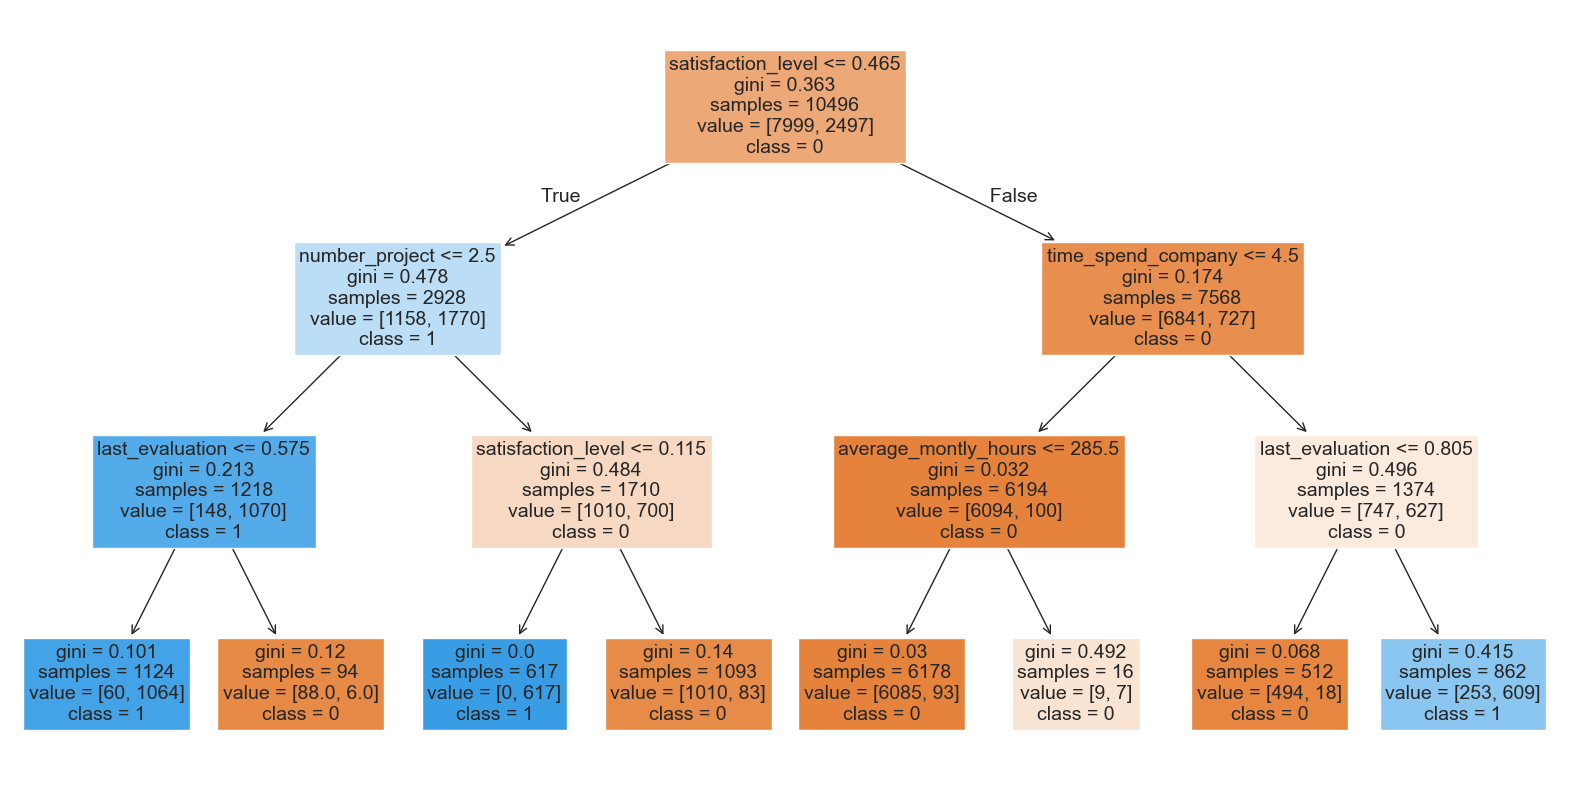

In [40]:
dtc = DecisionTreeClassifier(random_state=25,max_depth=3, min_samples_leaf=10)
dtc.fit(X_train_trns,y_train)
y_pred = dtc.predict(X_test_trns)
plt.figure(figsize=(20, 10))
plot_tree(dtc,
          feature_names=X_train_trns.columns,
          class_names=['0', '1'],
          filled=True,
          fontsize=14)
plt.show()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
trns = make_column_transformer((ohe, make_column_selector(dtype_include=object)), remainder='passthrough',
                               verbose_feature_names_out=False).set_output(transform='pandas')
X_train_trns = trns.fit_transform(X_train)
X_test_trns = trns.transform(X_test)

In [52]:
depths = [3,4,5,6,7,8,9,10,11,None]
leaves=[50,75,100,150]
splits=[50,75,100,150]
scores=[]
for d in depths:
    for l in leaves:
        for s in splits:
            dtc = DecisionTreeClassifier(random_state=25, max_depth=d,min_samples_leaf=l,min_samples_split=s)
            dtc.fit(X_train_trns,y_train)
            y_pred = dtc.predict(X_test_trns)
            scores.append([d,l,s, f1_score(y_test,y_pred, pos_label=1)])
df_scores = pd.DataFrame(scores, columns=['depth','Minimum leaf','Minimum sample slit', 'score'])
df_scores.sort_values(by='score', ascending=False,inplace=True)
df_scores

,depth,Minimum leaf,Minimum sample slit,score
96,9.0,50,50,0.936817
97,9.0,50,75,0.936817
98,9.0,50,100,0.936817
99,9.0,50,150,0.936817
115,10.0,50,150,0.936817
...,...,...,...,...
11,3.0,100,150,0.900461
12,3.0,150,50,0.888268
13,3.0,150,75,0.888268
14,3.0,150,100,0.888268


## Building best model on whole data

In [59]:
best_tree=DecisionTreeClassifier(random_state=25, min_samples_leaf=1,min_samples_split=2,max_depth=9)
X_trns=trns.fit_transform(X_train)
best_tree.fit(X_trns,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


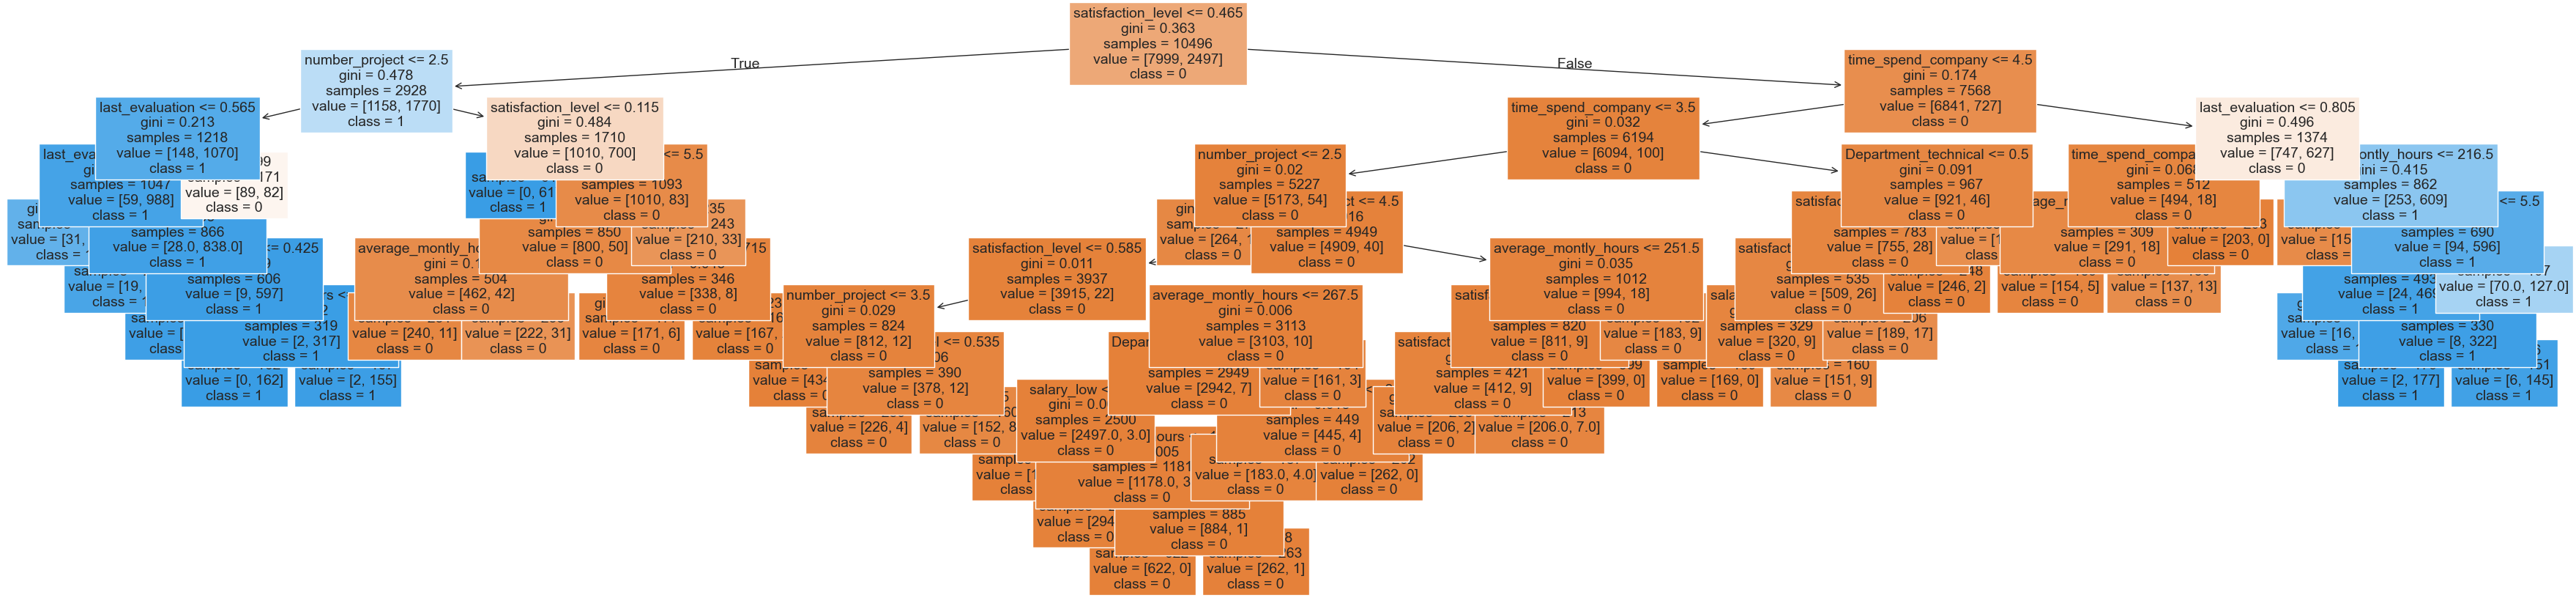

In [60]:
plt.figure(figsize=(45,10))
plot_tree(dtc,
          feature_names=X_train_trns.columns,
          class_names=['0', '1'],
          filled=True,
          fontsize=14)
plt.show()

In [64]:
df_imp=pd.DataFrame({'Feature':list(X_trns.columns),'importance':best_tree.feature_importances_})
df_imp.sort_values(by='importance',ascending=False,inplace=True)
df_imp

,Feature,importance
11,satisfaction_level,0.520221
15,time_spend_company,0.142225
12,last_evaluation,0.141069
13,number_project,0.113164
14,average_montly_hours,0.077932
16,Work_accident,0.001170
8,Department_technical,0.000787
5,Department_product_mng,0.000605
7,Department_support,0.000534
0,Department_RandD,0.000516


In [65]:
X_trns.columns

Index(['Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical', 'salary_low', 'salary_medium',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years'],
      dtype='object')

## Log Loss of Decision Tree

In [66]:
from sklearn.metrics import log_loss
best_tree=DecisionTreeClassifier(random_state=25, min_samples_leaf=1,min_samples_split=2,max_depth=9)
X_trns=trns.fit_transform(X_train)
best_tree.fit(X_trns,y_train)
y_pred_prob=best_tree.predict_proba(X_test_trns)
loss=log_loss(y_test,y_pred_prob)
print(loss)

0.20295792946469057


In [78]:
from sklearn.preprocessing import LabelEncoder
glass=pd.read_csv('Glass.csv')
y=glass['Type']
le=LabelEncoder()
y=le.fit_transform(y)
X=glass.drop('Type',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)
depths = [3,4,5,6,7,8,9,10,11,None]
leaves=[1,2,3,4,5,6,50,75,100,150]
splits=[2,3,4,5,6,50,75,100,150]
scores=[]
for d in depths:
    for l in leaves:
        for s in splits:
            dtc = DecisionTreeClassifier(random_state=25, max_depth=d,min_samples_leaf=l,min_samples_split=s)
            dtc.fit(X_train,y_train)
            y_pred = dtc.predict(X_test)
            y_pred_prob=dtc.predict_proba(X_test)
            scores.append([d,l,s,log_loss(y_test,y_pred_prob), f1_score(y_test,y_pred,average='macro')])
df_scores = pd.DataFrame(scores, columns=['depth','Minimum leaf','Minimum sample slit','Log Loss', 'score'])
df_scores.sort_values(by='Log Loss', ascending=True,inplace=True)
df_scores

,depth,Minimum leaf,Minimum sample slit,Log Loss,score
34,3.0,4,100,1.050118,0.369026
43,3.0,5,100,1.050118,0.369026
52,3.0,6,100,1.050118,0.369026
817,NaN,1,100,1.050118,0.369026
844,NaN,4,100,1.050118,0.369026
...,...,...,...,...,...
631,10.0,1,3,12.753908,0.590177
811,NaN,1,3,12.753908,0.590177
630,10.0,1,2,13.308426,0.585185
720,11.0,1,2,13.308426,0.555796


In [82]:
best_tree=DecisionTreeClassifier(random_state=25, min_samples_leaf=4,min_samples_split=100,max_depth=3)
best_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,100
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


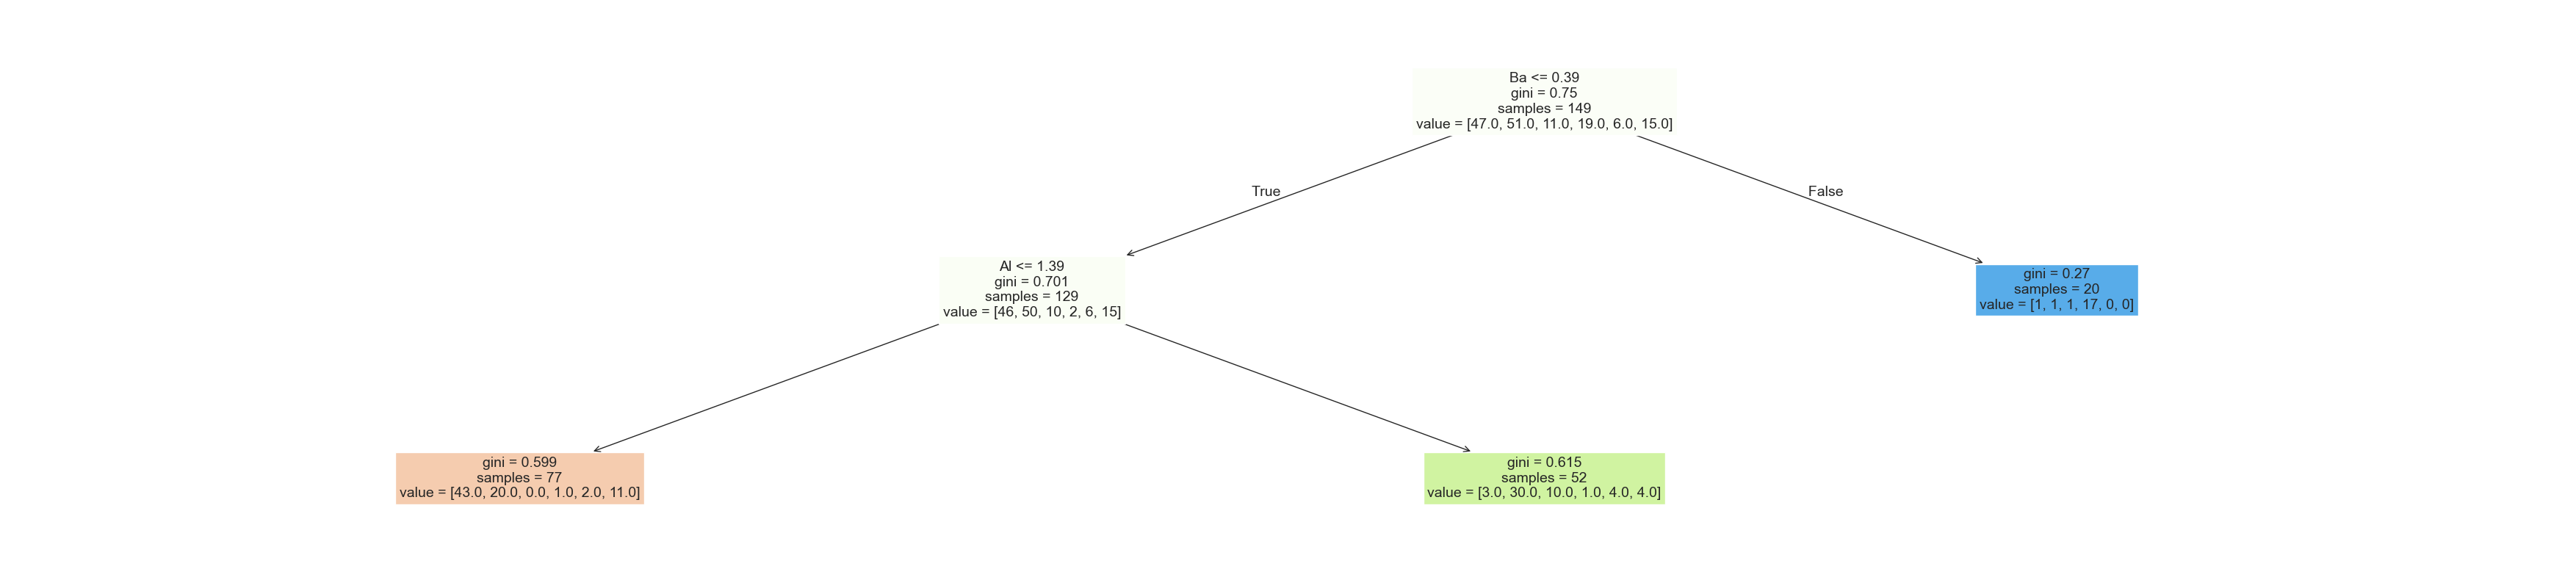

In [84]:
plt.figure(figsize=(45,10))
plot_tree(best_tree,
          feature_names=X_train.columns,
          #class_names=['0', '1'],
          filled=True,
          fontsize=14)
plt.show()

In [85]:
df_imp=pd.DataFrame({'Feature':list(X_trns.columns),'importance':best_tree.feature_importances_})
df_imp.sort_values(by='importance',ascending=False,inplace=True)
df_imp

,Feature,importance
7,Ba,0.565104
3,Al,0.434896
0,RI,0.000000
2,Mg,0.000000
1,Na,0.000000
4,Si,0.000000
5,K,0.000000
6,Ca,0.000000
8,Fe,0.000000


## Housing Data

In [92]:
housing = pd.read_csv('Housing.csv')
X = housing.drop(['price'], axis=1)
y = housing['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25)

In [93]:
trns = make_column_transformer((ohe, make_column_selector(dtype_include=object)), remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
X_train_trns=trns.fit_transform(X_train)
X_test_trns=trns.transform(X_test)

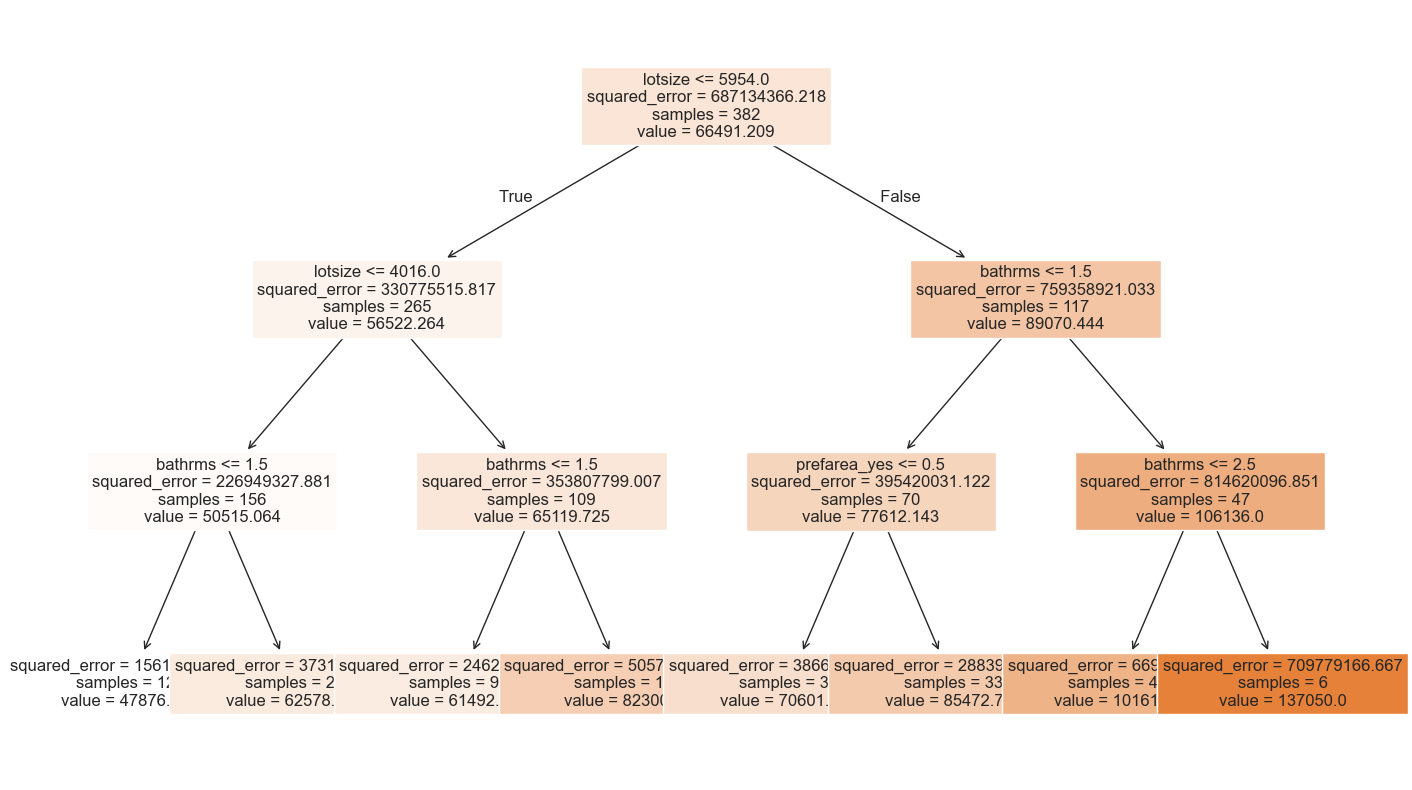

In [96]:
dtr = DecisionTreeRegressor(random_state=25, max_depth=3)
dtr.fit(X_train_trns,y_train)
plt.figure(figsize=(17,10))
plot_tree(dtr, feature_names=X_train_trns.columns, filled=True, fontsize=12)
plt.show()

In [101]:
depths = [3,4,5,6,7,8,9,10,11]
leaves=[1,5,10,20,50]
splits=[2,5,10,20,50]
scores=[]
for d in depths:
    for l in leaves:
        for s in splits:
            dtr = DecisionTreeRegressor(random_state=25, max_depth=d,min_samples_leaf=l,min_samples_split=s)
            dtr.fit(X_train_trns,y_train)
            y_pred = dtr.predict(X_test_trns)
            scores.append([d,l,s,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores, columns=['depth','Minimum leaf','Minimum sample slit', 'score'])
df_scores.sort_values('score', ascending=False, inplace=True)
df_scores

,depth,Minimum leaf,Minimum sample slit,score
128,8,1,20,0.520188
133,8,5,20,0.517948
153,9,1,20,0.515520
178,10,1,20,0.515169
53,5,1,20,0.514985
...,...,...,...,...
201,11,1,5,0.277624
100,7,1,2,0.228258
200,11,1,2,0.212990
175,10,1,2,0.186452


Text(0.5, 1.0, 'feature-Importance Plot')

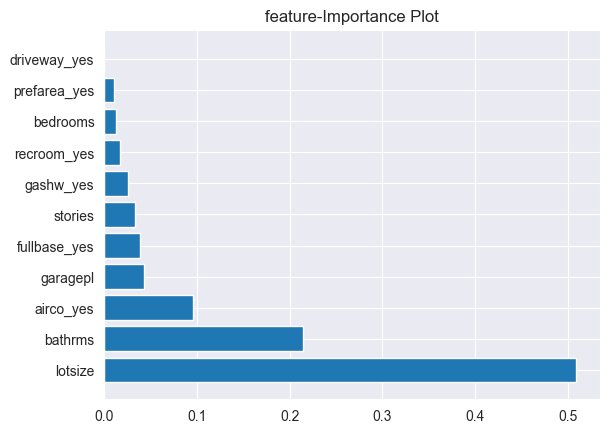

In [111]:
best_tree=DecisionTreeRegressor(random_state=25, min_samples_leaf=1,min_samples_split=20,max_depth=8)
X_trns = trns.fit_transform(X)
best_tree.fit(X_trns,y)

df_imp=pd.DataFrame({'Feature':list(X_trns.columns),'importance':best_tree.feature_importances_})
df_imp.sort_values(by='importance',ascending=False,inplace=True)
plt.barh(df_imp['Feature'],df_imp['importance'])
plt.title('feature-Importance Plot')

In [108]:
df_imp

,Feature,importance
6,lotsize,0.509114
8,bathrms,0.214331
4,airco_yes,0.095655
10,garagepl,0.042990
2,fullbase_yes,0.038394
9,stories,0.033116
3,gashw_yes,0.025585
1,recroom_yes,0.016801
7,bedrooms,0.013276
5,prefarea_yes,0.010738


## Concrete Strength

In [123]:
housing = pd.read_csv('Concrete_Data.csv')
X = housing.drop(['Strength'], axis=1)
y = housing['Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)
X_train

,Cement,Blast,Fly,Water,Superplasticizer,Coarse,Fine,Age
516,202.0,11.0,141.0,206.0,1.7,942.0,801.0,3
161,337.9,189.0,0.0,174.9,9.5,944.7,755.8,56
1019,139.7,163.9,127.7,236.7,5.8,868.6,655.6,28
815,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,3
870,149.0,139.0,109.0,193.0,6.0,892.0,780.0,28
...,...,...,...,...,...,...,...,...
255,212.5,0.0,100.4,159.3,8.7,1007.8,903.6,14
886,148.0,0.0,137.0,158.0,16.0,1002.0,830.0,28
143,375.0,93.8,0.0,126.6,23.4,852.1,992.6,56
474,446.0,24.0,79.0,162.0,10.3,967.0,712.0,28


In [122]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_train_scaled = pd.DataFrame(X_train_scaled,
#                                columns=X_train.columns,
#                                index=X_train.index)

array([[-0.78096604, -0.71672572,  1.33113646, ..., -0.3730911 ,
         0.33786383, -0.67463956],
       [ 0.52936405,  1.35718545, -0.85748163, ..., -0.33840894,
        -0.23564958,  0.17102229],
       [-1.38165452,  1.06474067,  1.12469235, ..., -1.31593202,
        -1.50702223, -0.27574246],
       ...,
       [ 0.88707742,  0.24799251, -0.85748163, ..., -1.52787855,
         2.76895166,  0.17102229],
       [ 1.57165017, -0.56526029,  0.36876539, ..., -0.05195999,
        -0.7913993 , -0.27574246],
       [-0.30080093, -0.84488877,  0.69317757, ...,  0.44900453,
         1.59147279,  0.87308118]], shape=(721, 8))

In [124]:
trns = make_column_transformer((ohe, make_column_selector(dtype_include=object)), remainder='passthrough',
                               verbose_feature_names_out=False).set_output(transform='pandas')
X_train_trns = trns.fit_transform(X_train)
X_test_trns = trns.transform(X_test)

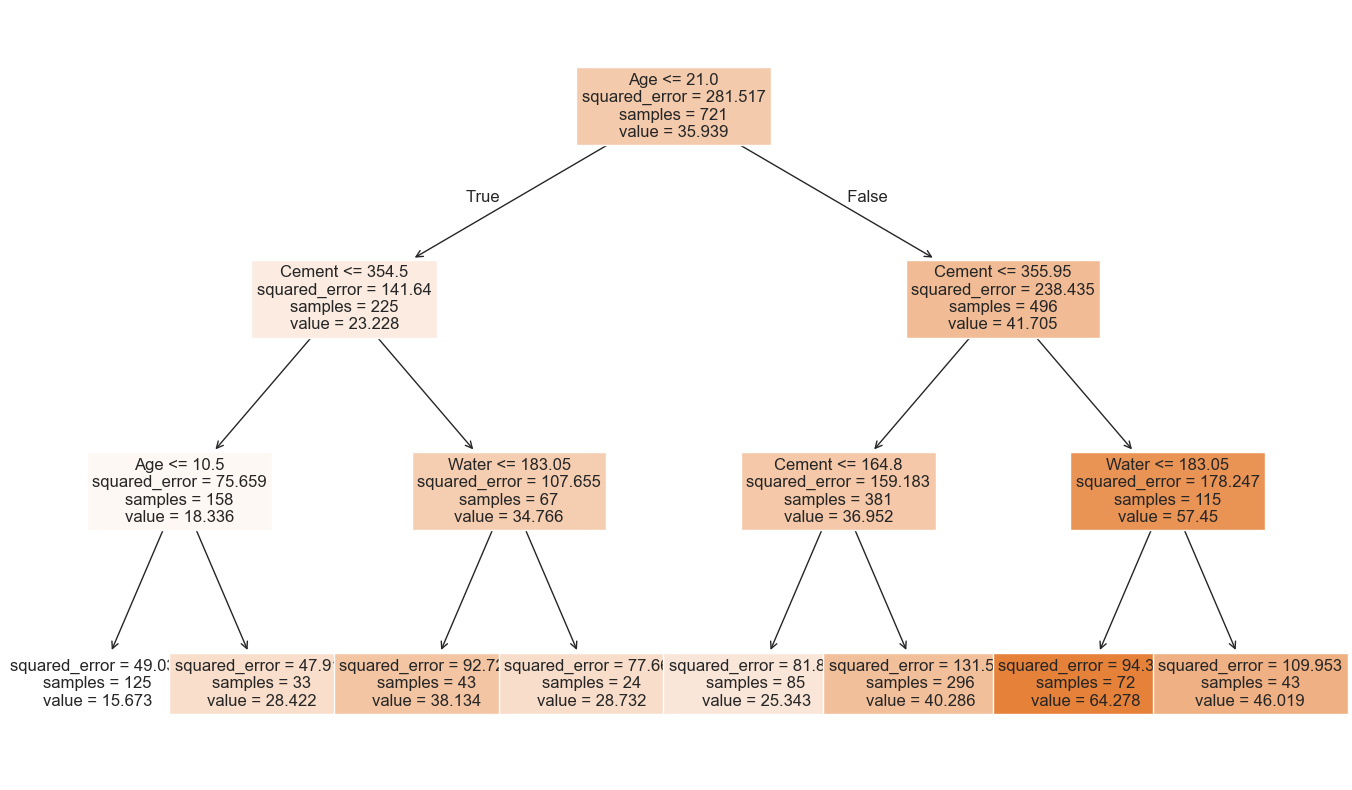

In [125]:
dtr = DecisionTreeRegressor(random_state=25, max_depth=3)
dtr.fit(X_train_trns, y_train)
plt.figure(figsize=(17, 10))
plot_tree(dtr, feature_names=X_train_trns.columns, filled=True, fontsize=12)
plt.show()

In [129]:
depths = [3,4,5,6,7,8,9,10,11]
leaves=[1,5,10,20,50]
splits=[2,5,10,20,50]
scores=[]
for d in depths:
    for l in leaves:
        for s in splits:
            dtr = DecisionTreeRegressor(random_state=25, max_depth=d,min_samples_leaf=l,min_samples_split=s)
            dtr.fit(X_train_trns,y_train)
            y_pred = dtr.predict(X_test_trns)
            scores.append([d,l,s,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores, columns=['depth','Minimum leaf','Minimum sample slit', 'score'])
df_scores.sort_values('score', ascending=False, inplace=True)
df_scores

,depth,Minimum leaf,Minimum sample slit,score
200,11,1,2,0.828274
202,11,1,10,0.820294
176,10,1,5,0.811620
150,9,1,2,0.811081
151,9,1,5,0.807458
...,...,...,...,...
20,3,50,2,0.534486
21,3,50,5,0.534486
23,3,50,20,0.534486
22,3,50,10,0.534486


Text(0.5, 1.0, 'feature-Importance Plot')

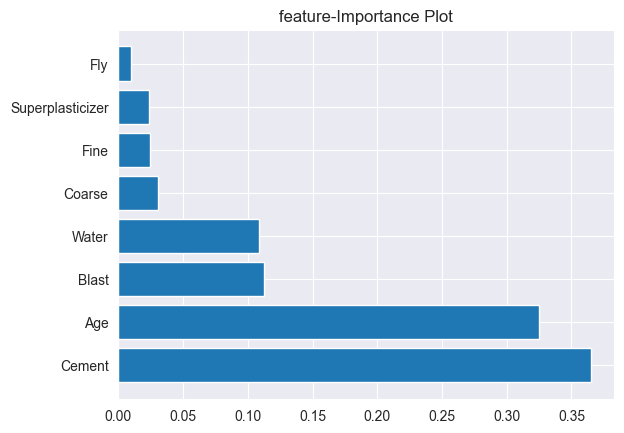

In [130]:
best_tree=DecisionTreeRegressor(random_state=25, min_samples_leaf=1,min_samples_split=2,max_depth=11)
X_trns = trns.fit_transform(X)
best_tree.fit(X_trns,y)

df_imp=pd.DataFrame({'Feature':list(X_trns.columns),'importance':best_tree.feature_importances_})
df_imp.sort_values(by='importance',ascending=False,inplace=True)
plt.barh(df_imp['Feature'],df_imp['importance'])
plt.title('feature-Importance Plot')

In [136]:
housing = pd.read_csv('Concrete_Data.csv')
X = housing.drop(['Strength'], axis=1)
y = housing['Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)
X_train

,Cement,Blast,Fly,Water,Superplasticizer,Coarse,Fine,Age
516,202.0,11.0,141.0,206.0,1.7,942.0,801.0,3
161,337.9,189.0,0.0,174.9,9.5,944.7,755.8,56
1019,139.7,163.9,127.7,236.7,5.8,868.6,655.6,28
815,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,3
870,149.0,139.0,109.0,193.0,6.0,892.0,780.0,28
...,...,...,...,...,...,...,...,...
255,212.5,0.0,100.4,159.3,8.7,1007.8,903.6,14
886,148.0,0.0,137.0,158.0,16.0,1002.0,830.0,28
143,375.0,93.8,0.0,126.6,23.4,852.1,992.6,56
474,446.0,24.0,79.0,162.0,10.3,967.0,712.0,28


In [137]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=X_train.columns,
                               index=X_train.index)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=X_test.columns,
                             index=X_test.index)

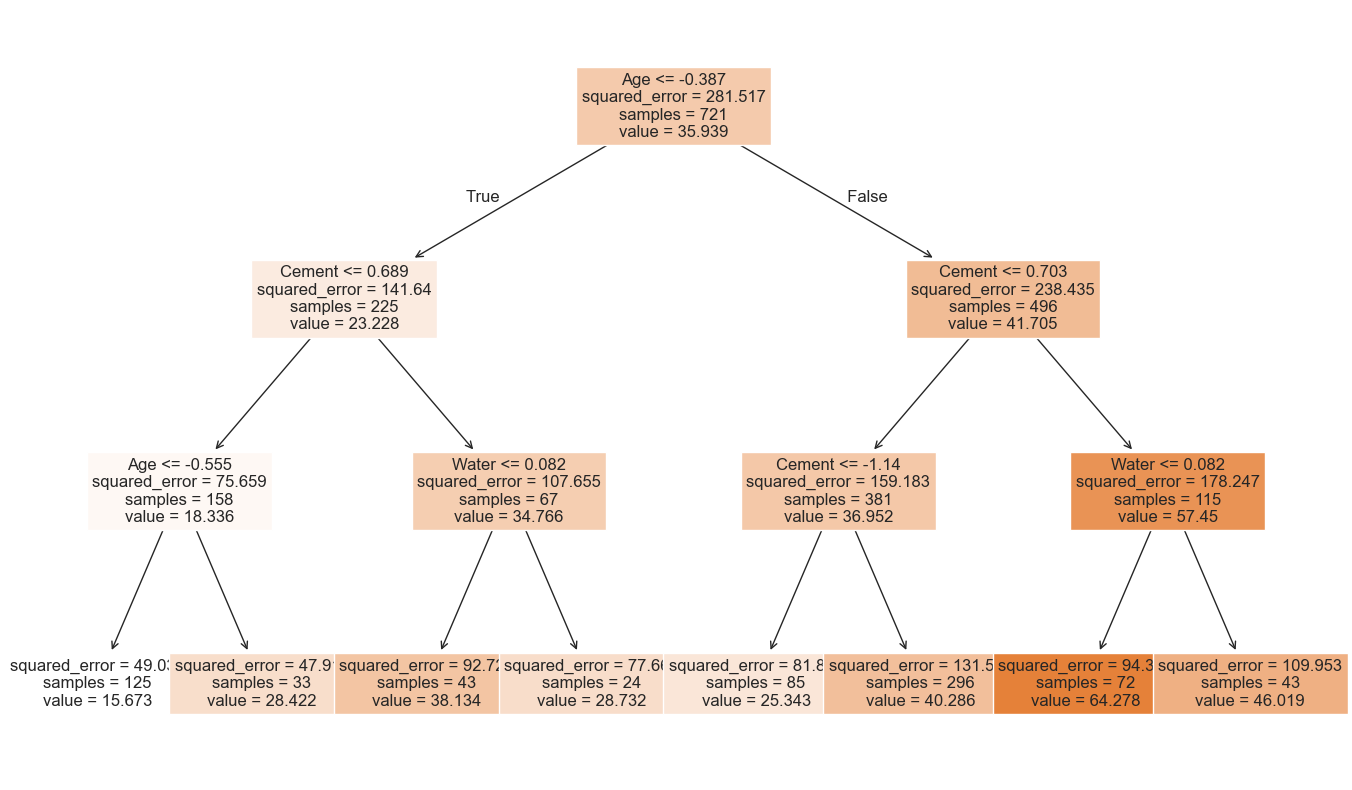

In [138]:
dtr = DecisionTreeRegressor(random_state=25, max_depth=3)
dtr.fit(X_train_scaled, y_train)
plt.figure(figsize=(17, 10))
plot_tree(dtr, feature_names=X_train_scaled.columns, filled=True, fontsize=12)
plt.show()

In [139]:
depths = [3,4,5,6,7,8,9,10,11]
leaves=[1,5,10,20,50]
splits=[2,5,10,20,50]
scores=[]
for d in depths:
    for l in leaves:
        for s in splits:
            dtr = DecisionTreeRegressor(random_state=25, max_depth=d,min_samples_leaf=l,min_samples_split=s)
            dtr.fit(X_train_scaled,y_train)
            y_pred = dtr.predict(X_test_scaled)
            scores.append([d,l,s,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores, columns=['depth','Minimum leaf','Minimum sample slit', 'score'])
df_scores.sort_values('score', ascending=False, inplace=True)
df_scores

,depth,Minimum leaf,Minimum sample slit,score
200,11,1,2,0.828274
202,11,1,10,0.820294
176,10,1,5,0.811620
150,9,1,2,0.811081
151,9,1,5,0.807458
...,...,...,...,...
20,3,50,2,0.534486
21,3,50,5,0.534486
23,3,50,20,0.534486
22,3,50,10,0.534486
